--- Model Evaluation ---
R-squared Score: 0.2249
RMSE: 5.2865



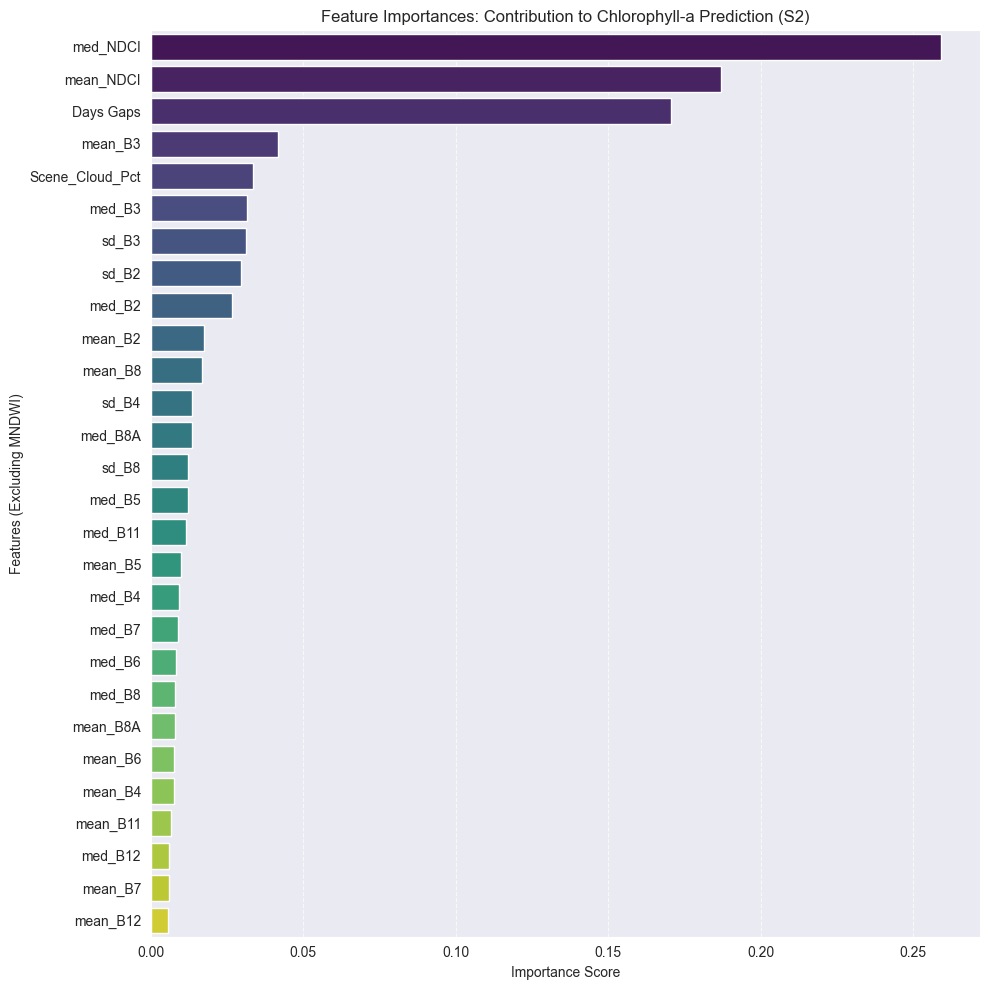

--- Feature Importance Ranking ---
        Feature  Importance
       med_NDCI    0.258977
      mean_NDCI    0.187040
      Days Gaps    0.170633
        mean_B3    0.041774
Scene_Cloud_Pct    0.033656
         med_B3    0.031706
          sd_B3    0.031198
          sd_B2    0.029714
         med_B2    0.026623
        mean_B2    0.017491
        mean_B8    0.016720
          sd_B4    0.013632
        med_B8A    0.013396
          sd_B8    0.012262
         med_B5    0.012166
        med_B11    0.011599
        mean_B5    0.010039
         med_B4    0.009140
         med_B7    0.008861
         med_B6    0.008331
         med_B8    0.008017
       mean_B8A    0.007815
        mean_B6    0.007707
        mean_B4    0.007457
       mean_B11    0.006542
        med_B12    0.006128
        mean_B7    0.005839
       mean_B12    0.005537


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('Tappan_S2_Bands_NDCI_MNDWI_30mBuffer.csv')

target_col = 'Target Variable(Chlorophyll-a)'

original_features = df.columns[11:35].tolist()

additional_features = ['mean_NDCI', 'med_NDCI', 'Scene_Cloud_Pct', 'Days Gaps']
feature_cols = original_features + additional_features

data = df[[target_col] + feature_cols].dropna()

X = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation ---")
print(f"R-squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}\n")

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue = 'Feature', legend=False)
plt.title('Feature Importances: Contribution to Chlorophyll-a Prediction (S2)')
plt.xlabel('Importance Score')
plt.ylabel('Features (Excluding MNDWI)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


print("--- Feature Importance Ranking ---")
print(feature_importance_df.to_string(index=False))

Here I have checked the individual R2 score for each of the column

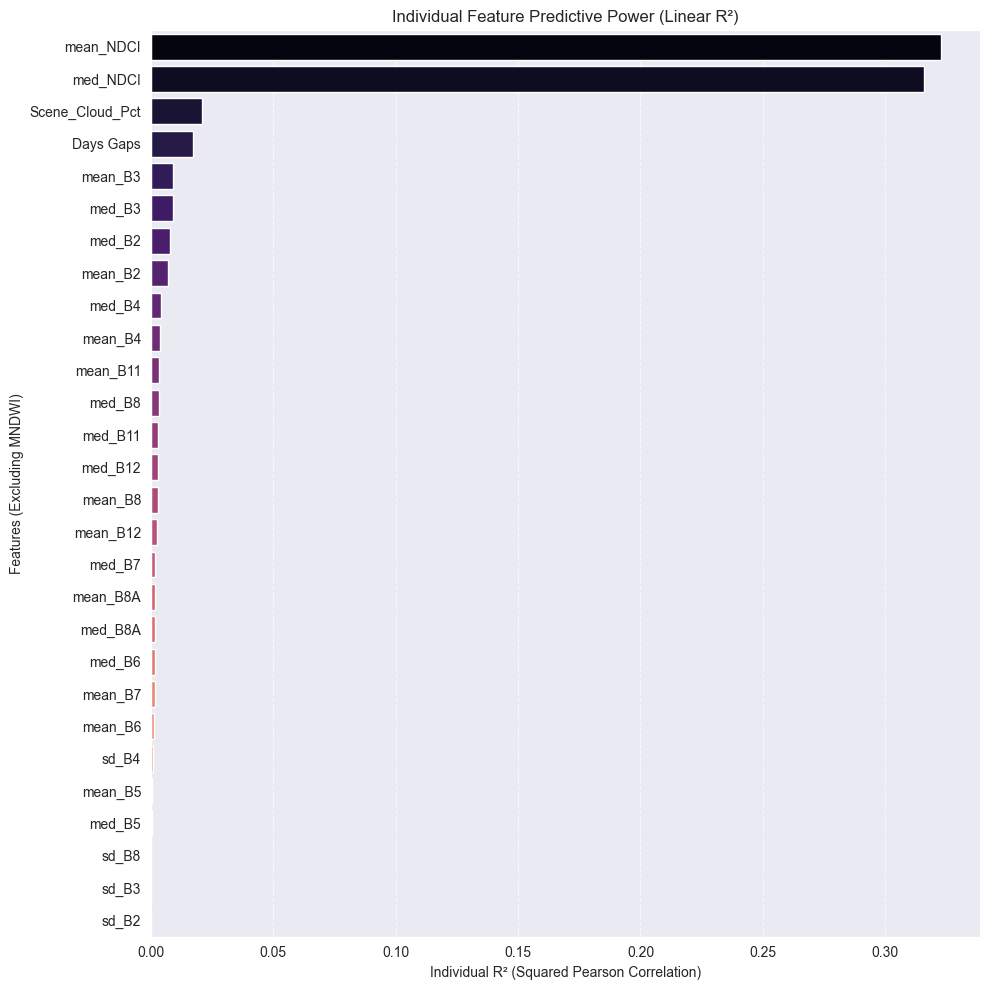

--- Individual Feature R2 Ranking ---
        Feature  Individual R2 Score
      mean_NDCI             0.322525
       med_NDCI             0.315749
Scene_Cloud_Pct             0.021029
      Days Gaps             0.017071
        mean_B3             0.009258
         med_B3             0.009251
         med_B2             0.007921
        mean_B2             0.007007
         med_B4             0.004143
        mean_B4             0.003679
       mean_B11             0.003202
         med_B8             0.003159
        med_B11             0.003115
        med_B12             0.002863
        mean_B8             0.002758
       mean_B12             0.002719
         med_B7             0.001788
       mean_B8A             0.001763
        med_B8A             0.001639
         med_B6             0.001582
        mean_B7             0.001552
        mean_B6             0.001419
          sd_B4             0.000974
        mean_B5             0.000672
         med_B5             0.000569


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

df = pd.read_csv('Tappan_S2_Bands_NDCI_MNDWI_30mBuffer.csv')
target_col = 'Target Variable(Chlorophyll-a)'

original_features = df.columns[11:35].tolist()
additional_features = ['mean_NDCI', 'med_NDCI', 'Scene_Cloud_Pct', 'Days Gaps']
feature_cols = original_features + additional_features

data = df[[target_col] + feature_cols].dropna()

linear_r2_scores = []
for feat in feature_cols:
    r, _ = pearsonr(data[feat], data[target_col])
    linear_r2_scores.append({'Feature': feat, 'Individual R2 Score': r**2})

linear_r2_df = pd.DataFrame(linear_r2_scores).sort_values(by='Individual R2 Score', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x='Individual R2 Score', y='Feature', data=linear_r2_df, palette='magma', hue = 'Feature', legend=False)
plt.title('Individual Feature Predictive Power (Linear R²)')
plt.xlabel('Individual R² (Squared Pearson Correlation)')
plt.ylabel('Features (Excluding MNDWI)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Individual Feature R2 Ranking ---")
print(linear_r2_df.to_string(index=False))